In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD


In [6]:
df = pd.read_csv('mental_wellness.csv')
# df = df.drop(columns=['Unnamed: 0', 'axis='])
df.head()

,Sleep_Hours,Sleep_Quality,Physical_Activity_Min,Diet_Quality,Stress_Level
0,10.0,0,41,1,3
1,5.7,2,36,1,8
2,7.5,2,7,1,8
3,5.6,2,35,0,5
4,7.3,0,29,0,1


In [7]:
df.shape

(1485, 5)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1485 entries, 0 to 1484
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sleep_Hours            1485 non-null   float64
 1   Sleep_Quality          1485 non-null   int64  
 2   Physical_Activity_Min  1485 non-null   int64  
 3   Diet_Quality           1485 non-null   int64  
 4   Stress_Level           1485 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 58.1 KB


In [9]:
cols = [
    "Sleep_Hours",
    "Sleep_Quality",
    "Physical_Activity_Min",
    "Diet_Quality",
    "Stress_Level"
]

df = df[cols].copy()


In [10]:
# drop duplicates
df = df.drop_duplicates()

# drop rows with missing
df = df.dropna()


In [11]:
le = LabelEncoder()

df["Sleep_Quality"] = le.fit_transform(df["Sleep_Quality"])
df["Diet_Quality"] = le.fit_transform(df["Diet_Quality"])


In [12]:
num_cols = [
    "Sleep_Hours",
    "Physical_Activity_Min",
    "Stress_Level"
]

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = ~((df[num_cols] < lower) | (df[num_cols] > upper)).any(axis=1)

df_clean = df[mask].reset_index(drop=True)

print("Rows after cleaning:", len(df_clean))


Rows after cleaning: 1465


In [13]:
X = df_clean.values

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
svd3 = TruncatedSVD(n_components=3, random_state=42)
X_3D = svd3.fit_transform(X_scaled)

df_clean["C1"] = X_3D[:,0]
df_clean["C2"] = X_3D[:,1]
df_clean["C3"] = X_3D[:,2]

In [16]:
df_clean["HealthScore"] = (
    df_clean["Sleep_Hours"]
    + df_clean["Sleep_Quality"] * 2
    + df_clean["Diet_Quality"] * 2
    + df_clean["Physical_Activity_Min"] / 20
    - df_clean["Stress_Level"] * 2
)


In [17]:
df_clean["HealthScore_Stretched"] = df_clean["HealthScore"] * 5


In [18]:
X_floor = df_clean[[
    "HealthScore_Stretched",
    "Sleep_Hours",
    "Physical_Activity_Min"
]].values


In [19]:
df_clean["FloorCluster"] = pd.qcut(
    df_clean["HealthScore"],
    q=6,
    labels=False
)


In [20]:
from sklearn.preprocessing import StandardScaler

X_floor_scaled = StandardScaler().fit_transform(X_floor)

In [21]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, n_init=50, random_state=42)
df_clean["FloorCluster"] = kmeans.fit_predict(X_floor_scaled)


In [22]:
from sklearn.decomposition import TruncatedSVD

svd3 = TruncatedSVD(n_components=3, random_state=42)
X_3D = svd3.fit_transform(X_floor_scaled)

df_clean["C1"] = X_3D[:,0]
df_clean["C2"] = X_3D[:,1]
df_clean["C3"] = X_3D[:,2]


In [23]:
fig = px.scatter_3d(
    df_clean,
    x="C1",
    y="C2",
    z="C3",
    color="FloorCluster",
    title="Separated Health Floors (Stretched Axis)"
)

fig.show()


### --

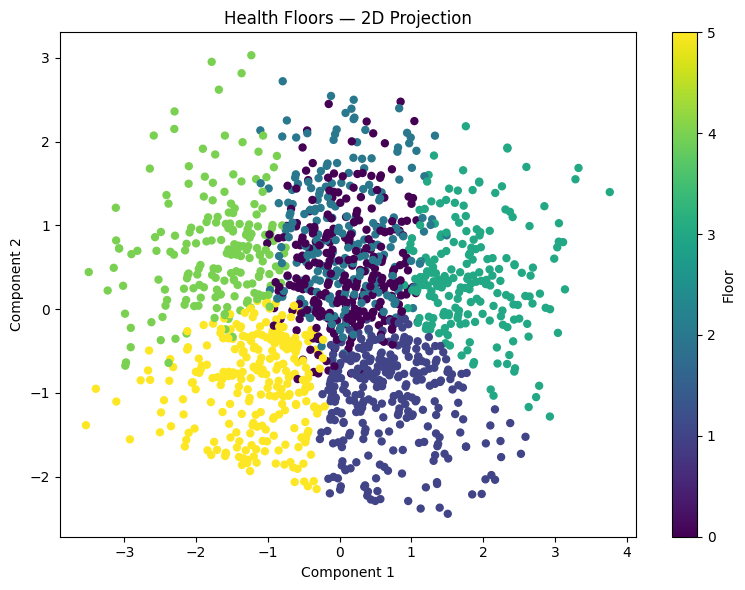

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(
    df_clean["C1"],
    df_clean["C2"],
    c=df_clean["FloorCluster"],
    s=25
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Health Floors — 2D Projection")
plt.colorbar(label="Floor")
plt.tight_layout()
plt.show()


In [25]:
fig = px.scatter_3d(
    df_clean,
    x="C1",
    y="C2",
    z="C3",
    color="FloorCluster",
    title="6 Health Floors — Stratified Segmentation"
)

fig.show()


In [26]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np

# Feature space used for evaluation
X_eval = X_scaled   # same scaled features used earlier
labels = df_clean["FloorCluster"].values

# Silhouette score (overall)
sil_score = silhouette_score(X_eval, labels)
print("Silhouette Score (Floors):", sil_score)

Silhouette Score (Floors): 0.11230921525572005


In [27]:
sample_scores = silhouette_samples(X_eval, labels)

print("Average silhouette:", np.mean(sample_scores))
print("Min silhouette:", np.min(sample_scores))
print("Max silhouette:", np.max(sample_scores))

Average silhouette: 0.11230921525572005
Min silhouette: -0.07359695330119459
Max silhouette: 0.35379571745700195


In [28]:
# Save results for the Meta-Model
df.to_csv('Mental_Wellness.csv', index=False)
print("Mental Wellness results exported to Mental_Wellness.csv")

Mental Wellness results exported to Mental_Wellness.csv


In [29]:
import pickle
with open('mental_kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)